In [1]:
import numpy as np
from scipy.stats import norm
import xarray as xr
import pandas as pd

In [2]:
dust_df = pd.read_csv("DATA/processed/3_dust_points_vars_2026-06-12.csv")
control_ds = xr.open_dataset("DATA/processed/4_control_grid_2026-06-10.nc")

In [3]:
#--- Percent comparison
variable = "usage"
category = 9

# percent_dust_df = (dust_df[variable] == category).mean() * 100
percent_dust_df = np.sum(dust_df[variable] == category)/len(dust_df) * 100
# percent_control_ds = (control_ds[variable] == category).mean().item() * 100
percent_control_ds = np.sum(control_ds[variable] == category).values/control_ds[variable].count().values * 100
print(f"Dust: {round(percent_dust_df,3)}")
print(f"Control: {round(percent_control_ds, 3)}")

Dust: 13.402
Control: 2.317


In [4]:
#--- Proportion t-test (two-proportion test)
x1 = (dust_df[variable] == category).sum()
n1 = len(dust_df)

x2 = (control_ds[variable] == category).sum().item()
n2 = control_ds[variable].size

p1 = x1 / n1
p2 = x2 / n2

p_pool = (x1 + x2) / (n1 + n2)

z = (p1 - p2) / np.sqrt(
    p_pool * (1 - p_pool) * (1/n1 + 1/n2)
)

p_value = 2 * (1 - norm.cdf(abs(z)))

print(f"z: {round(z, 3)}")
print(f"p vallue: {round(p_value, 3)}")

z: 33.486
p vallue: 0.0


Getting usage names and choosing which to plot...
Building and plotting the usage cumulative distribution function...


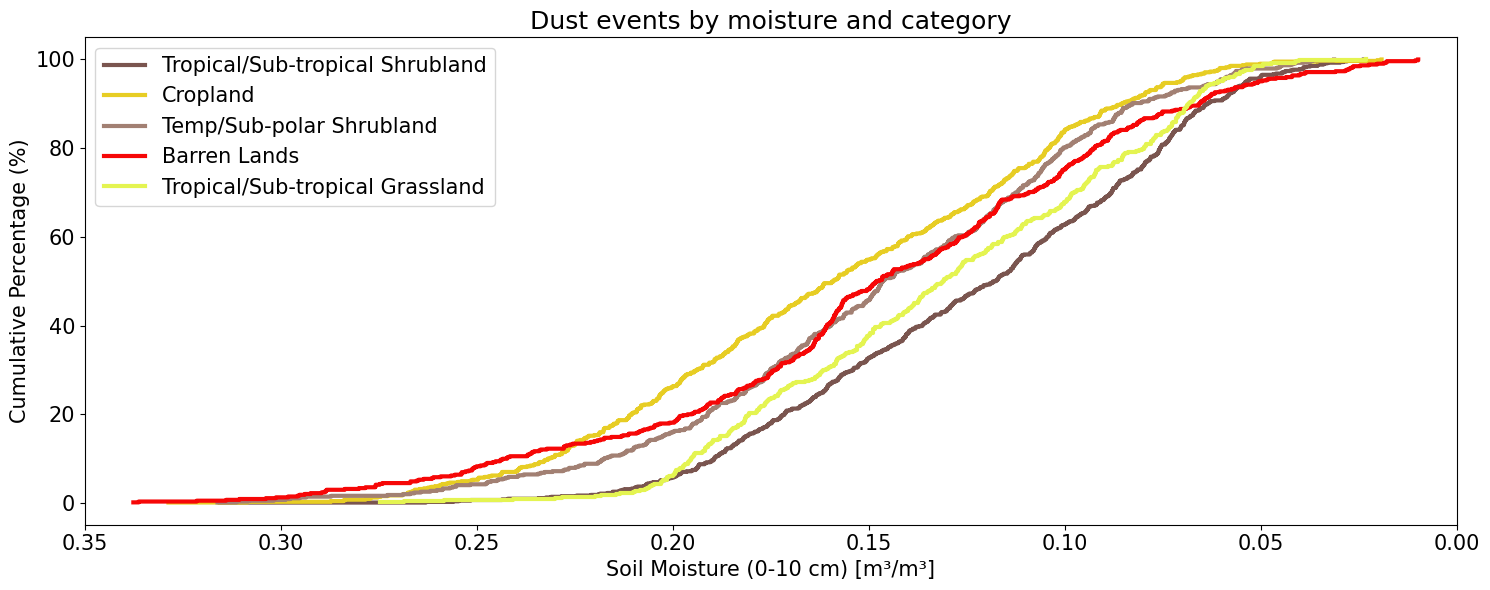

Getting soil order names and choosing which to plot...
Building and plotting the order cumulative distribution function...


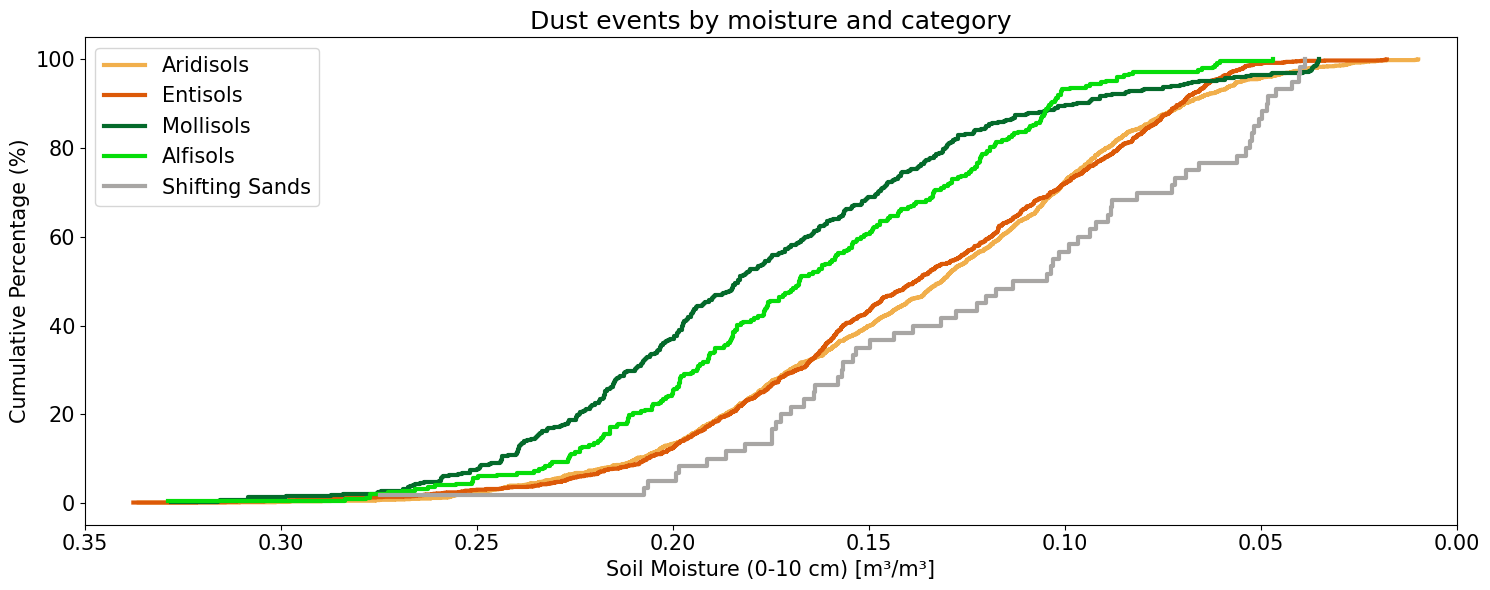

Getting texture names and choosing which to plot...
Building and plotting the order cumulative distribution function...


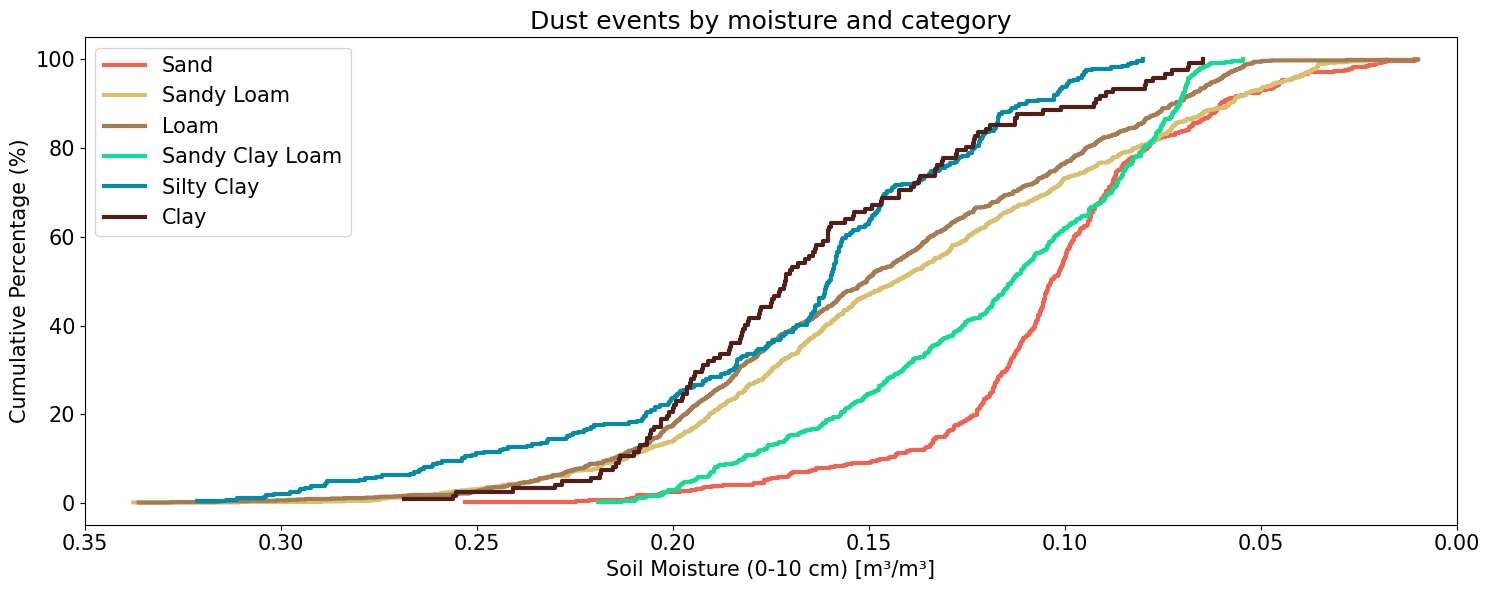

Getting usage names and choosing which to plot...
Building and plotting the usage cumulative distribution function...


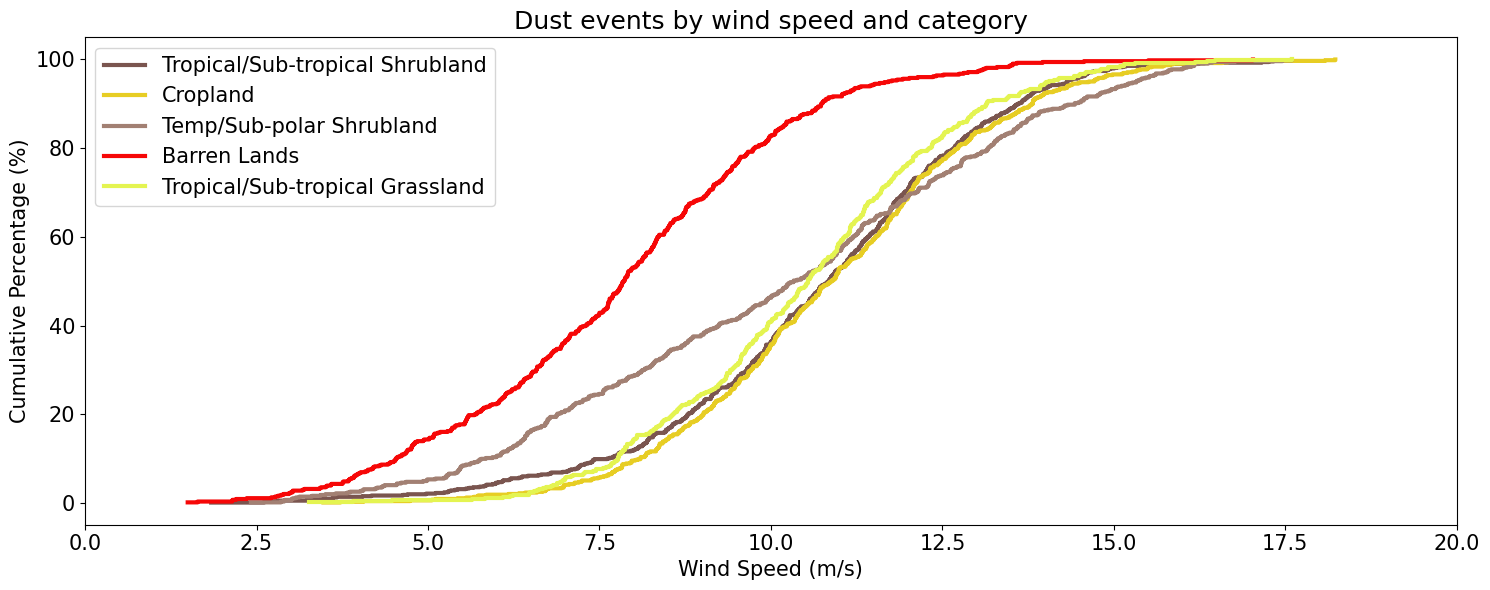

Getting soil order names and choosing which to plot...
Building and plotting the order cumulative distribution function...


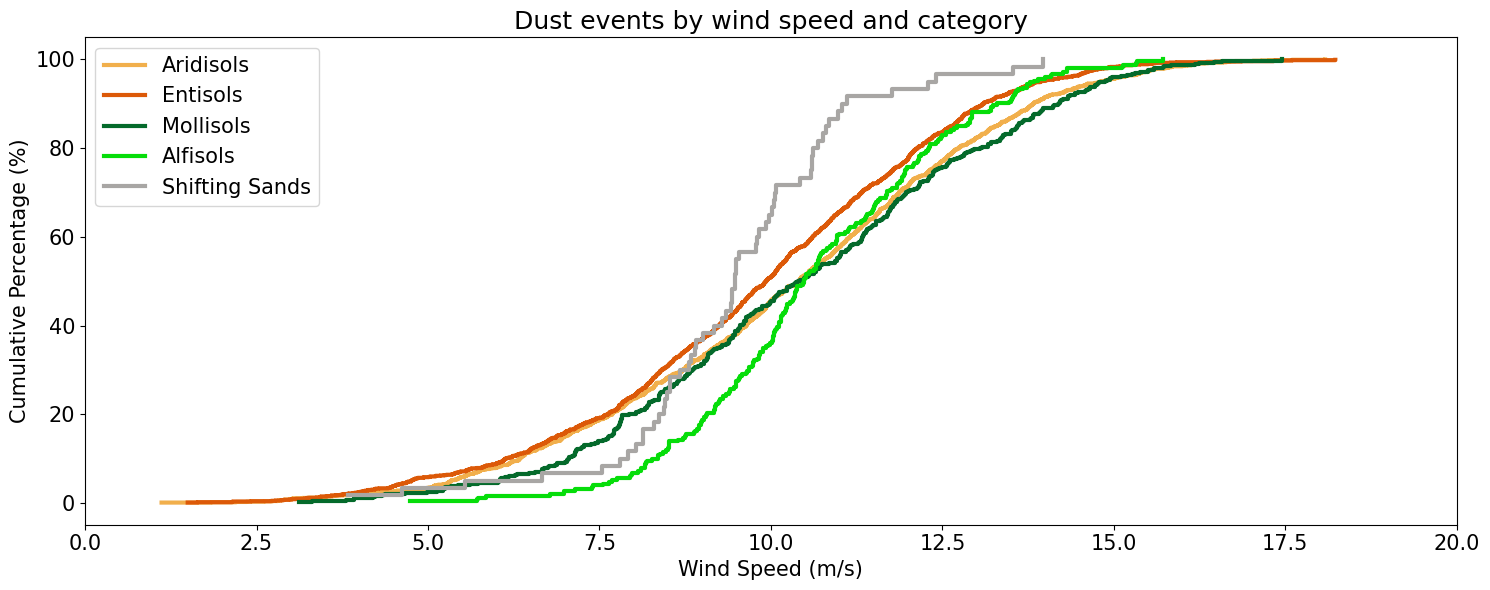

Getting texture names and choosing which to plot...
Building and plotting the order cumulative distribution function...


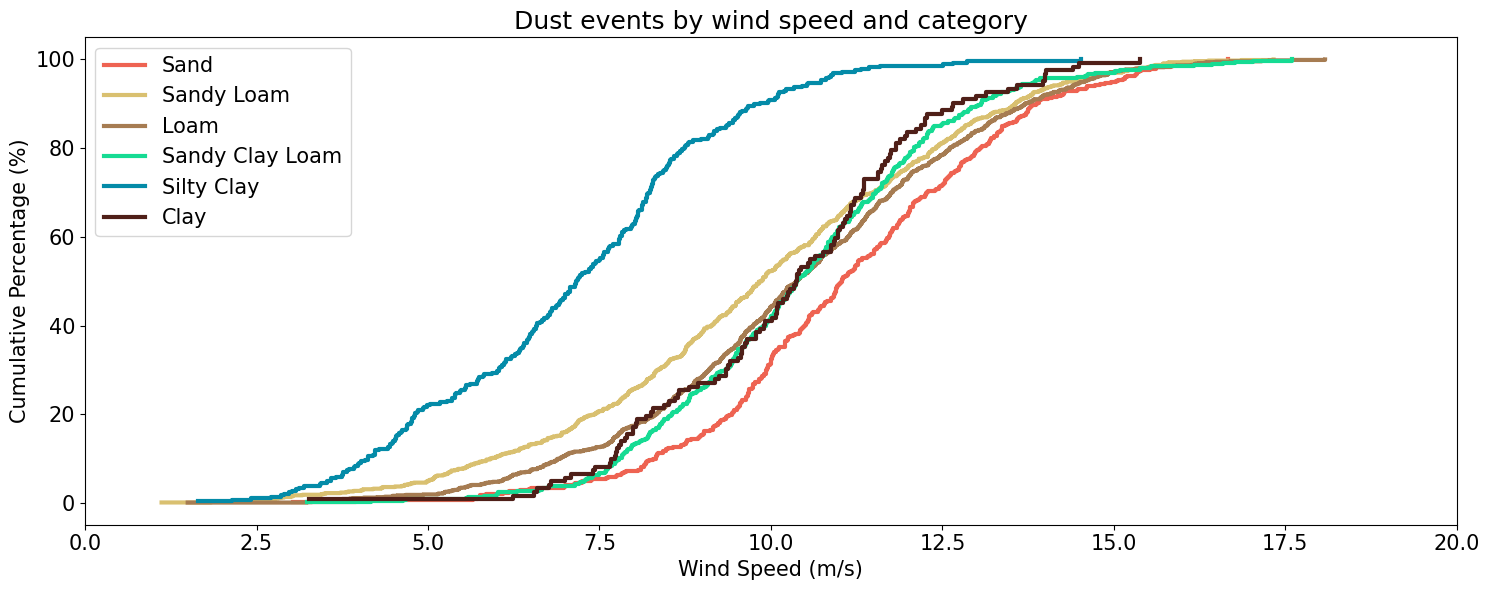

Making moisture categories...
Building and plotting the order cumulative distribution function...


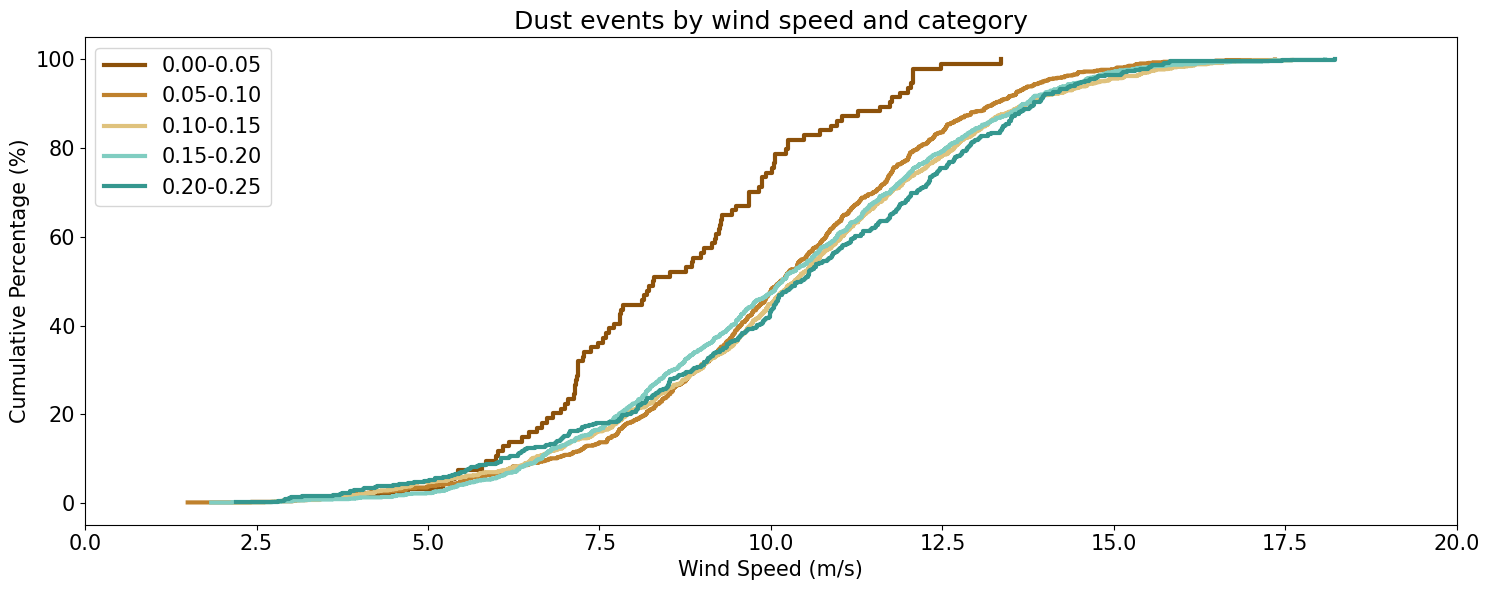

In [5]:
from importnb import Notebook

with Notebook():
    import ANALYSIS_cdf_plots as cdf

In [ ]:
#--- CDF analysis (moisture bins)
dust_df_sorted, column_name, selected_list, colors = cdf.moisture_info_for_cdf(dust_df)

In [ ]:
#--- CDF analysis (surface cover)
dust_df_sorted, column_name, selected_list, colors = cdf.usage_info_for_cdf(dust_df)

Getting usage names and choosing which to plot...
Building and plotting the usage cumulative distribution function...


In [7]:
threshold_wind = 7.5
threshold_moist = 0.15
category = 'Temp/Sub-polar Shrubland'

# subset = dust_df_sorted
subset = dust_df_sorted[dust_df_sorted['usage_name'] == category]

idx = (subset['wind_speed'] - threshold_wind).abs().idxmin()
threshold_sel_wind = subset.loc[[idx]]

idx = (subset['moisture'] - threshold_wind).abs().idxmin()
threshold_sel_moist = subset.loc[[idx]]

print(f"{category} at {threshold_wind} m/s: {round(threshold_sel_wind['cum_pct'].values[0], 2)}%")
print(f"{category} at {threshold_moist} m3/m3: {round(threshold_sel_moist['cum_pct'].values[0], 2)}%")

Temp/Sub-polar Shrubland at 7.5 m/s: 24.63%
Temp/Sub-polar Shrubland at 0.15 m3/m3: 4.07%
